#  Import Library & Load data

In [2]:
import pandas as pd
import jsonlines
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

with jsonlines.open("../data/raw_dataset.jsonl") as reader:
    data = list(reader)

df = pd.DataFrame(data)
print(f"Total samples: {len(df)}")
df.head()

Total samples: 1500


,text,label
0,I just saw a charge on my bank statement that ...,billing
1,I would like to request a copy of my invoices ...,billing
2,"My payment failed, but the money already left ...",billing
3,Could you please help me update my credit card...,billing
4,"Hey, my bill is way higher than usual. Why?",billing


label
billing         250
technical       250
cancellation    250
upgrade         250
complaint       250
api             250
Name: count, dtype: int64


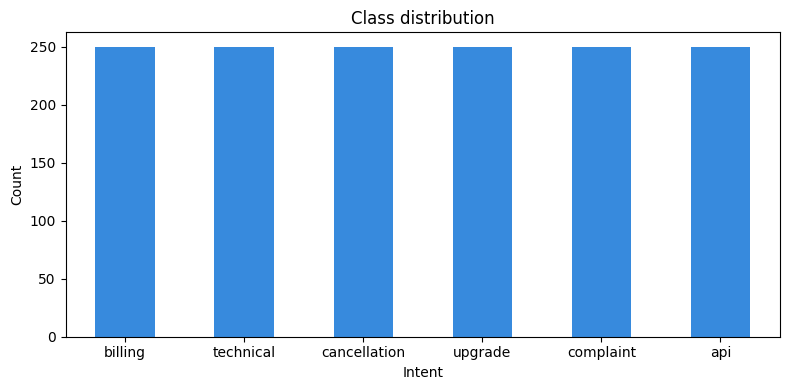

In [3]:
dist = df["label"].value_counts()
print(dist)

plt.figure(figsize=(8, 4))
dist.plot(kind="bar", color="#378ADD")
plt.title("Class distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
duplicates = df[df.duplicated(subset=["text"])]
print(f"Duplicate rows: {len(duplicates)}")
duplicates.head()

Duplicate rows: 32


,text,label
106,Please provide a VAT invoice for my last payment.,billing
123,Do you guys accept PayPal for payments?,billing
125,Where can I find my latest invoice?,billing
180,Why am I being charged for something I didn't ...,billing
204,I think I was overcharged for this month's ser...,billing


              count  mean   std   min   25%   50%    75%    max
label                                                          
api           250.0  83.7  34.4  28.0  57.2  79.5  110.0  187.0
billing       250.0  68.5  26.2  18.0  49.0  65.0   82.8  146.0
cancellation  250.0  52.3  16.0  15.0  41.0  52.5   62.0  102.0
complaint     250.0  57.0  24.2  14.0  39.0  55.0   72.0  129.0
technical     250.0  75.0  31.3  17.0  49.2  72.0  102.0  147.0
upgrade       250.0  69.3  22.6  19.0  55.0  68.5   82.0  129.0


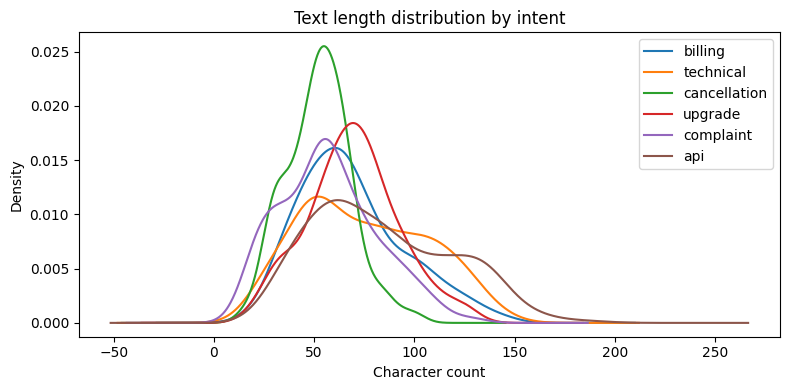

In [5]:
df["length"] = df["text"].str.len()

print(df.groupby("label")["length"].describe().round(1))

plt.figure(figsize=(8, 4))
for label in df["label"].unique():
    subset = df[df["label"] == label]["length"]
    subset.plot(kind="kde", label=label)
plt.title("Text length distribution by intent")
plt.xlabel("Character count")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
empty    = df[df["text"].str.strip() == ""]
too_short = df[df["length"] < 10]

print(f"Empty  : {len(empty)}")
print(f"Too short (<10 chars): {len(too_short)}")
too_short

Empty  : 0
Too short (<10 chars): 0


,text,label,length


In [7]:
valid_labels = {"billing","technical","cancellation","upgrade","complaint","api"}
invalid = df[~df["label"].isin(valid_labels)]
print(f"Invalid labels: {len(invalid)}")
invalid

Invalid labels: 0


,text,label,length


In [8]:
for label in sorted(valid_labels):
    print(f"\n{'─'*40}")
    print(f"[{label.upper()}]")
    samples = df[df["label"] == label].sample(3)["text"].tolist()
    for s in samples:
        print(f"  • {s}")


────────────────────────────────────────
[API]
  • The /users endpoint is returning a 500 error for certain IDs. Any idea why?
  • How do I verify the webhook signature to make sure it's actually from you?
  • What is the maximum payload size for the POST /upload endpoint?

────────────────────────────────────────
[BILLING]
  • I need a VAT invoice for my company records.
  • I don't understand this line item on my invoice.
  • I would like to request a PDF copy of my invoice for October.

────────────────────────────────────────
[CANCELLATION]
  • Hey, I want to opt out of the renewal for next year.
  • I've had enough, please terminate my membership.
  • I want out. Cancel my account.

────────────────────────────────────────
[COMPLAINT]
  • Your response times are an absolute disgrace.
  • Just terrible.
  • I didn't realize that ignoring customers was part of your official business strategy.

────────────────────────────────────────
[TECHNICAL]
  • The password reset link is retur

In [ ]:
print("="*40)
print("DATA QUALITY SUMMARY")
print("="*40)
print(f"Total samples    : {len(df)}")
print(f"Duplicates       : {len(duplicates)}")
print(f"Empty text       : {len(empty)}")
print(f"Too short        : {len(too_short)}")
print(f"Invalid labels   : {len(invalid)}")
print(f"Balanced classes : {dist.min() == dist.max()}")
print("="*40)

if len(duplicates) == 0 and len(empty) == 0 and len(invalid) == 0:
    print("Data is clean — ready for cleaning script")
else:
    print("Issues found")

DATA QUALITY SUMMARY
Total samples    : 1500
Duplicates       : 32
Empty text       : 0
Too short        : 0
Invalid labels   : 0
Balanced classes : True
Issues found — cần clean trước khi split
